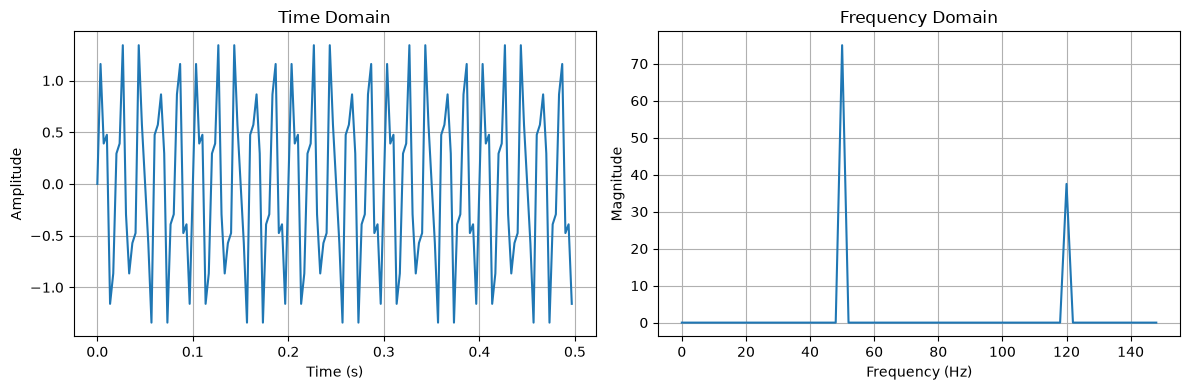

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Sampling
fs = 250  # Hz
T = 0.5  # second
t = np.arange(0, T, 1 / fs)
x = np.sin(2 * np.pi * 50 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)  # Signal: 50 Hz + 120 Hz
X = np.fft.fft(x)  # FFT
freq = np.fft.fftfreq(len(x), d=1 / fs)
half = len(freq) // 2  # Only positive frequencies


fig, ax = plt.subplots(1, 2, figsize=(12, 4))  # Create one figure with two plots

ax[0].plot(t, x)

ax[0].set_title("Time Domain")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Amplitude")
ax[0].grid()

ax[1].plot(freq[:half], np.abs(X[:half]))
ax[1].set_title("Frequency Domain")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude")
ax[1].grid()

plt.tight_layout()
plt.show()

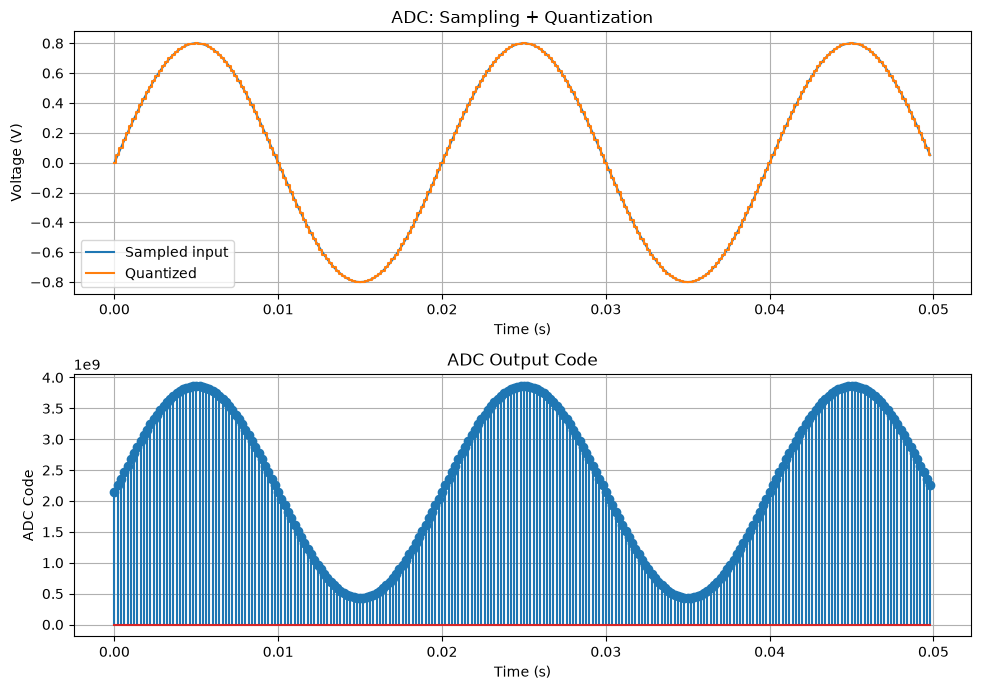

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# Analog signal
# -------------------------
f_signal = 50       # Hz
fs = 5000           # ADC sampling frequency
duration = 0.05     # second

t = np.arange(0, duration, 1/fs)

x = 0.8 * np.sin(2*np.pi*f_signal*t)

# -------------------------
# ADC parameters
# -------------------------
bits = 32
Vmin = -1
Vmax = 1

levels = 2**bits

# Quantization step
delta = (Vmax - Vmin) / levels

# -------------------------
# Quantization
# -------------------------

# Clip to ADC input range
x_clipped = np.clip(x, Vmin, Vmax)

# Convert voltage -> ADC integer code
adc_code = np.floor(
    (x_clipped - Vmin) / delta
)

adc_code = np.clip(adc_code, 0, levels - 1)

# Convert code back to quantized voltage
x_quantized = Vmin + (adc_code + 0.5) * delta

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Original sampled signal + quantized signal
ax[0].plot(t, x, label="Sampled input")
ax[0].step(
    t,
    x_quantized,
    where="mid",
    label="Quantized"
)

ax[0].set_title("ADC: Sampling + Quantization")
ax[0].set_xlabel("Time (s)")
ax[0].set_ylabel("Voltage (V)")
ax[0].grid()
ax[0].legend()

# Digital ADC code
ax[1].stem(t, adc_code)

ax[1].set_title("ADC Output Code")
ax[1].set_xlabel("Time (s)")
ax[1].set_ylabel("ADC Code")
ax[1].grid()

plt.tight_layout()
plt.show()